# Build Graph from Parquet Data

This notebook loads Telegram channel and message data from Parquet files and builds a NetworkX graph.

**Data Sources:**
- `data/telegram_channels.parquet` - Channel metadata
- `data/telegram_messages.parquet` - Message data


In [2]:
# Install dependencies if needed
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Install required packages
%pip install -q networkx pandas pyarrow matplotlib seaborn



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Import libraries
import pandas as pd
# import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns   

# Import graph builder
from src.disinfograph.gnn.graph_builder import load_parquet_data, build_graph_for_neo4j

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Step 2: Build Graph


In [5]:
forwards_messages_df = load_parquet_data('/Users/yuliavistak/Desktop/UCU/Навчання/4 курс/diploma/TeleNarratives/src/disinfograph/gnn/data/labeled_messages_forwards.parquet')
forwards_messages_df.head()

,channel_id,message_id,channel_username,is_reply,reply_to_msg_id,is_forwarded,fwd_from_channel_id,fwd_from_message_id,date_utc,views,...,text,sub_narrative_id,sub_narrative,narrative_id,narrative,meta_narrative_id,meta_narrative,label,confidence,embedding
0,1331641097,96994,donbassr,False,NaN,False,<NA>,<NA>,2025-10-17 09:08:07+00:00,105314,...,российские войска по некоторым данным закрепил...,294,Підтримка Заходу лише відтягує поразку України,21,Перемога України неможлива,2,Підрив віри в перемогу України,1,0.9,"[0.051471792, -0.010424209, 0.0026195627, 0.00..."
1,1331641097,96761,donbassr,False,NaN,False,<NA>,<NA>,2025-10-13 06:52:32+00:00,114828,...,пароль дерилово отзыв святогорск кипят бои за ...,230,Київ перешкоджає роботі делегації МАГАТЕ на ЗАЕС,17,Нацизм в Україні,8,Дискредитація України та її інституцій,1,1.0,"[-0.01759927, -0.018814042, -0.016132027, -0.0..."
2,1331641097,96040,donbassr,False,NaN,False,<NA>,<NA>,2025-09-30 08:05:32+00:00,95889,...,уроки краснолиманского направления наступление...,294,Підтримка Заходу лише відтягує поразку України,21,Перемога України неможлива,2,Підрив віри в перемогу України,1,1.0,"[-0.03336752, 0.019523123, -0.024035476, -0.02..."
3,1331641097,95603,donbassr,False,NaN,False,<NA>,<NA>,2025-09-22 13:51:17+00:00,96935,...,где тонко там и рвется а у всу фронт истончает...,300,Український наступ провалився,21,Перемога України неможлива,2,Підрив віри в перемогу України,1,0.9,"[-0.0098496545, 0.036795437, -0.046713565, -0...."
4,1331641097,95117,donbassr,False,NaN,False,<NA>,<NA>,2025-09-13 14:05:29+00:00,105121,...,восток продолжает вбивать клин в оборонительну...,294,Підтримка Заходу лише відтягує поразку України,21,Перемога України неможлива,2,Підрив віри в перемогу України,1,0.9,"[-0.054819785, 0.025619874, -0.03353434, -0.01..."


In [6]:
semantic_similarity_pairs_df = load_parquet_data('/Users/yuliavistak/Desktop/UCU/Навчання/4 курс/diploma/TeleNarratives/src/disinfograph/gnn/data/labeled_semantic_similarity_pairs.parquet')
semantic_similarity_pairs_df.head()

,src_channel_id,src_message_id,src_date_utc,dst_channel_id,dst_message_id,dst_date_utc,similarity_score,sub_narrative_id,sub_narrative,narrative_id,narrative,meta_narrative_id,meta_narrative,label,src_embedding,dst_embedding,src_channel_username,src_text,dst_channel_username,dst_text
0,1200595041,81903,2025-05-13 09:15:44+00:00,1184797808,43676,2025-05-13 10:07:01+00:00,0.997168,12,Країни ЄС хочуть поділити Україну,2,Союзники хочуть поділити Україну,2,Підрив віри в перемогу України,1,"[0.06412709, -0.006538983, -0.025383122, 0.035...","[0.06631566, -0.0072922567, -0.028716315, 0.04...",OpenUkraine,венгрия венгерские танки и бронетехника были з...,Novorossia_Region,венгрия венгерские танки и бронетехника были з...
1,1352726486,92196,2025-02-08 10:01:14+00:00,1197363285,153359,2025-02-08 11:00:37+00:00,0.997167,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,"[-0.008394196, -0.01678771, 0.0064423513, -0.0...","[-0.0128850965, -0.018324535, 0.008898905, -0....",insiderUKR,михайло поплавський у топ інфлюенсерів україни...,u_now,михайло поплавський у топ інфлюенсерів україни...
2,1199360700,106709,2025-02-08 09:07:26+00:00,1352726486,92196,2025-02-08 10:01:14+00:00,0.997167,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,"[-0.0128850965, -0.018324535, 0.008898905, -0....","[-0.008394196, -0.01678771, 0.0064423513, -0.0...",truexanewsua,михайло поплавський у топ інфлюенсерів україни...,insiderUKR,михайло поплавський у топ інфлюенсерів україни...
3,1352726486,92196,2025-02-08 10:01:14+00:00,1233777422,94403,2025-02-08 13:00:18+00:00,0.997167,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,"[-0.008394196, -0.01678771, 0.0064423513, -0.0...","[-0.0128850965, -0.018324535, 0.008898905, -0....",insiderUKR,михайло поплавський у топ інфлюенсерів україни...,UaOnlii,михайло поплавський у топ інфлюенсерів україни...
4,1187502427,134953,2025-04-28 11:21:41+00:00,1697554072,82697,2025-04-28 11:22:41+00:00,0.997163,339,Україна обстрілює цивільну інфраструктуру,24,Україна і Захід відмовляються починати мирні п...,7,Україна/Захід винні — Росія захищається,1,"[-0.005185975, -0.021613132, -0.041310187, -0....","[-0.0020362872, -0.022806028, -0.043420002, -0...",kherson_news_info,президент россии объявил перемирие в дни летия...,MonitoringUA,президент россии объявил перемирие в дни летия...


In [7]:
def build_messages_df(
    forwards_messages_df: pd.DataFrame,
    semantic_similarity_pairs_df: pd.DataFrame,
) -> pd.DataFrame:
    COLS = [
        "channel_id", "message_id", "fwd_from_channel_id", "fwd_from_message_id",
        "sub_narrative_id", "narrative_id", "meta_narrative_id", "label",
        "channel_username", "text", "sub_narrative", "narrative", "meta_narrative", "date_utc", "embedding"
    ]

    base_df = forwards_messages_df[COLS].copy()
    existing = set(zip(base_df["channel_id"], base_df["message_id"]))

    def _extract_side(pairs_df, id_col, msg_col, username_col, text_col, date_col, embedding_col, existing_set):
        unique_ids = pairs_df[[id_col, msg_col]].drop_duplicates()
        mask = ~unique_ids.apply(
            lambda r: (r[id_col], r[msg_col]) in existing_set, axis=1
        )
        new_rows = pairs_df.loc[unique_ids.index[mask]]
        return pd.DataFrame({
            "channel_id":          new_rows[id_col].values,
            "message_id":          new_rows[msg_col].values,
            "fwd_from_channel_id": pd.NA,
            "fwd_from_message_id": pd.NA,
            "sub_narrative_id":    new_rows["sub_narrative_id"].values,
            "narrative_id":        new_rows["narrative_id"].values,
            "meta_narrative_id":   new_rows["meta_narrative_id"].values,
            "label":               new_rows["label"].values,
            "channel_username":    new_rows[username_col].values,
            "text":                new_rows[text_col].values,
            "sub_narrative":       new_rows["sub_narrative"].values,
            "narrative":           new_rows["narrative"].values,
            "meta_narrative":      new_rows["meta_narrative"].values,
            "date_utc":            new_rows[date_col].values,
            "embedding":           new_rows[embedding_col].values,
        })

    src_df = _extract_side(
        semantic_similarity_pairs_df,
        "src_channel_id", "src_message_id",
        "src_channel_username", "src_text", "src_date_utc", "src_embedding",
        existing,
    )
    existing |= set(zip(src_df["channel_id"], src_df["message_id"]))

    dst_df = _extract_side(
        semantic_similarity_pairs_df,
        "dst_channel_id", "dst_message_id",
        "dst_channel_username", "dst_text", "dst_date_utc", "dst_embedding",
        existing,
    )

    messages_df = pd.concat([base_df, src_df, dst_df], ignore_index=True)
    return messages_df

In [8]:
messages_df = build_messages_df(forwards_messages_df, semantic_similarity_pairs_df)
print(f"forwards_messages_df:          {len(forwards_messages_df):,} rows")
print(f"semantic_similarity_pairs_df:  {len(semantic_similarity_pairs_df):,} rows")
print(f"messages_df (combined):        {len(messages_df):,} rows")
messages_df.head()

forwards_messages_df:          70,595 rows
semantic_similarity_pairs_df:  10,872 rows
messages_df (combined):        81,369 rows


/var/folders/tl/165vkc4d64z11m4p76hwcldr0000gn/T/ipykernel_39564/940041836.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  messages_df = pd.concat([base_df, src_df, dst_df], ignore_index=True)


,channel_id,message_id,fwd_from_channel_id,fwd_from_message_id,sub_narrative_id,narrative_id,meta_narrative_id,label,channel_username,text,sub_narrative,narrative,meta_narrative,date_utc,embedding
0,1331641097,96994,<NA>,<NA>,294,21,2,1,donbassr,российские войска по некоторым данным закрепил...,Підтримка Заходу лише відтягує поразку України,Перемога України неможлива,Підрив віри в перемогу України,2025-10-17 09:08:07+00:00,"[0.051471792, -0.010424209, 0.0026195627, 0.00..."
1,1331641097,96761,<NA>,<NA>,230,17,8,1,donbassr,пароль дерилово отзыв святогорск кипят бои за ...,Київ перешкоджає роботі делегації МАГАТЕ на ЗАЕС,Нацизм в Україні,Дискредитація України та її інституцій,2025-10-13 06:52:32+00:00,"[-0.01759927, -0.018814042, -0.016132027, -0.0..."
2,1331641097,96040,<NA>,<NA>,294,21,2,1,donbassr,уроки краснолиманского направления наступление...,Підтримка Заходу лише відтягує поразку України,Перемога України неможлива,Підрив віри в перемогу України,2025-09-30 08:05:32+00:00,"[-0.03336752, 0.019523123, -0.024035476, -0.02..."
3,1331641097,95603,<NA>,<NA>,300,21,2,1,donbassr,где тонко там и рвется а у всу фронт истончает...,Український наступ провалився,Перемога України неможлива,Підрив віри в перемогу України,2025-09-22 13:51:17+00:00,"[-0.0098496545, 0.036795437, -0.046713565, -0...."
4,1331641097,95117,<NA>,<NA>,294,21,2,1,donbassr,восток продолжает вбивать клин в оборонительну...,Підтримка Заходу лише відтягує поразку України,Перемога України неможлива,Підрив віри в перемогу України,2025-09-13 14:05:29+00:00,"[-0.054819785, 0.025619874, -0.03353434, -0.01..."


In [9]:
def get_channels_df(messages_df: pd.DataFrame) -> pd.DataFrame:
    # base channels df
    channels_df = (
        messages_df[["channel_id", "channel_username"]]
        .drop_duplicates(subset=["channel_id"])
        .reset_index(drop=True)
    )

    # aggregate stats per channel
    channel_stats = (
        messages_df
        .groupby("channel_id")
        .agg(
            messages_posted=("message_id", "count"),
            positive_ratio=("label", "mean")  # since label is 0/1
        )
        .reset_index()
    )

    # merge with channels
    channels_df = channels_df.merge(channel_stats, on="channel_id", how="left")

    # compute channel_label
    channels_df["channel_label"] = (
        (channels_df["messages_posted"] >= 50) &
        (channels_df["positive_ratio"] >= 0.6)
    ).astype(int)

    channels_df["positive_ratio"] = round(channels_df["positive_ratio"], 2)

    return channels_df

In [10]:
channels_df = get_channels_df(messages_df)
print(channels_df.info())
channels_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   channel_id        95 non-null     Int64  
 1   channel_username  95 non-null     string 
 2   messages_posted   95 non-null     Int64  
 3   positive_ratio    95 non-null     Float64
 4   channel_label     95 non-null     int64  
dtypes: Float64(1), Int64(2), int64(1), string(1)
memory usage: 4.1 KB
None


,channel_id,channel_username,messages_posted,positive_ratio,channel_label
0,1331641097,donbassr,128,0.98,1
1,1101170442,rian_ru,1211,0.83,1
2,1260622817,readovkanews,254,0.83,1
3,1175084215,ukr_2025_ru,857,0.87,1
4,1631471668,herson_today,512,0.98,1


In [11]:
# Build graph
print("\nBuilding graph...")
G = build_graph_for_neo4j(
    channels_df,
    messages_df,
    semantic_similarity_pairs_df=semantic_similarity_pairs_df,
)

print(f"\n✓ Graph built successfully!")
print(f"  Total Nodes: {G.number_of_nodes():,}")
print(f"  Total Edges: {G.number_of_edges():,}")



Building graph...

✓ Graph built successfully!
  Total Nodes: 81,464
  Total Edges: 163,875


## Step 3: Graph Statistics


In [12]:
# Count nodes by type
node_types = {}
for _, data in G.nodes(data=True):
    node_type = data.get("node_type", "unknown")
    node_types[node_type] = node_types.get(node_type, 0) + 1

print("📊 Node Types Count:")
for node_type, count in sorted(node_types.items()):
    print(f"  {node_type}: {count:,}")

# Count edges by type
edge_types = {}
for _, _, data in G.edges(data=True):
    edge_type = data.get("type", "unknown")
    edge_types[edge_type] = edge_types.get(edge_type, 0) + 1

print(f"\n📊 Edge Types Count:")
for edge_type, count in sorted(edge_types.items()):
    print(f"  {edge_type}: {count:,}")

# Graph properties
print(f"\n📈 Graph Properties:")
print(f"  Is Directed: {G.is_directed()}")
print(f"  Is Multigraph: {G.is_multigraph()}")
if G.number_of_nodes() > 0:
    print(f"  Average Degree: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")


📊 Node Types Count:
  channel: 95
  message: 81,369

📊 Edge Types Count:
  FORWARD_FROM: 71,634
  POSTED: 81,369
  SIMILAR_TO: 10,872

📈 Graph Properties:
  Is Directed: True
  Is Multigraph: True
  Average Degree: 4.02


## Step 4: Visualize Node and Edge Type Distribution


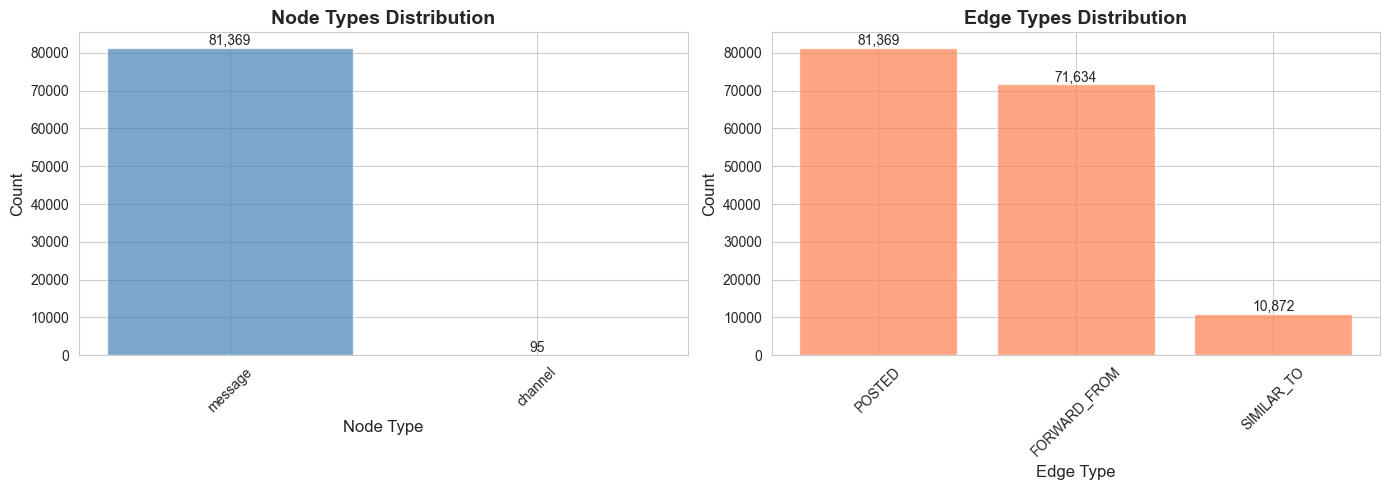

In [13]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Node types bar chart
node_types_sorted = sorted(node_types.items(), key=lambda x: x[1], reverse=True)
node_labels, node_counts = zip(*node_types_sorted) if node_types_sorted else ([], [])

axes[0].bar(node_labels, node_counts, color='steelblue', alpha=0.7)
axes[0].set_title('Node Types Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Node Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(node_counts):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# Edge types bar chart
edge_types_sorted = sorted(edge_types.items(), key=lambda x: x[1], reverse=True)
edge_labels, edge_counts = zip(*edge_types_sorted) if edge_types_sorted else ([], [])

axes[1].bar(edge_labels, edge_counts, color='coral', alpha=0.7)
axes[1].set_title('Edge Types Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Edge Type', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(edge_counts):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


## Step 5: Push Graph to Neo4j (Local)

Push the graph data to a **local Neo4j database** for graph database queries and analysis.

### Setting Up Local Neo4j

**Option 1: Using Docker (Recommended)**
```bash
docker run -d \
  --name neo4j \
  -p 7474:7474 -p 7687:7687 \
  -e NEO4J_AUTH=neo4j/your_password \
  neo4j:latest
```

**Option 2: Using Homebrew (macOS)**
```bash
brew install neo4j
brew services start neo4j
```

**Option 3: Download from [neo4j.com](https://neo4j.com/download/)**

After installation, access Neo4j Browser at: `http://localhost:7474`

### Configuration

**Note:** Set `NEO4J_PASSWORD` in your `.env` file (default URI is `bolt://localhost:7687`):
```
NEO4J_PASSWORD=your_local_password
```

### Setting/Resetting Neo4j Password

**If you get an authentication error**, you need to set or reset your Neo4j password:

**Option 1: Using Neo4j Browser (Easiest)**
1. Open http://localhost:7474 in your browser
2. Login with default credentials:
   - Username: `neo4j`
   - Password: `neo4j` (or the password you set when starting Neo4j)
3. You'll be prompted to change the password - set a new password
4. Update `NEO4J_PASSWORD` in your `.env` file with the new password

**Option 2: Using Docker Cypher Shell**
```bash
docker exec -it neo4j cypher-shell -u neo4j -p neo4j
# Then run:
ALTER CURRENT USER SET PASSWORD FROM 'neo4j' TO 'your_new_password';
```

**Option 3: Reset Docker Neo4j (if you forgot password)**
```bash
docker stop neo4j
docker rm neo4j
docker run -d --name neo4j -p 7474:7474 -p 7687:7687 -e NEO4J_AUTH=neo4j/your_password neo4j:latest
```

**Limit for Testing:** Set `NEO4J_LIMIT_RECORDS` to limit the number of messages/channels pushed.

In [15]:
# Import Neo4j loader
from src.disinfograph.gnn.neo4j_loader import load_graph_to_neo4j
from src.disinfograph.config import get_neo4j_config

# Configuration for Neo4j push
PUSH_TO_NEO4J = True  # Set to True to push data to Neo4j
CLEAR_DATABASE = True  # Set to True to clear existing data before pushing (use with caution!)
NEO4J_LIMIT_RECORDS = None  # Limit messages/channels for testing (set to None to push all)

# IMPORTANT: This notebook is configured to use LOCAL Neo4j by default
# Default URI: bolt://localhost:7687 (if NEO4J_URI not set in .env)
# Make sure you have:
#   1. Neo4j running locally (Docker/Homebrew/etc.)
#   2. NEO4J_PASSWORD set in .env file
# The notebook will verify it's connecting to local Neo4j before pushing data

if PUSH_TO_NEO4J:
    try:
        # Get Neo4j configuration from environment variables
        neo4j_config = get_neo4j_config()
        
        print("📤 Pushing graph data to Neo4j...")
        print(f"  URI: {neo4j_config['uri']}")
        print(f"  Database: {neo4j_config['database']}")
        print(f"  Clear database: {CLEAR_DATABASE}")
        
        # Verify it's local Neo4j
        uri_lower = neo4j_config['uri'].lower()
        is_local = any(local in uri_lower for local in ['localhost', '127.0.0.1', 'bolt://localhost', 'neo4j://localhost'])
        if is_local:
            print("  ✓ Using LOCAL Neo4j instance")
        else:
            print("  ⚠️  WARNING: Not using local Neo4j!")
            print(f"     Current URI: {neo4j_config['uri']}")
            print("     To use local Neo4j, set NEO4J_URI=bolt://localhost:7687 in .env")
            print("     Or remove NEO4J_URI to use default (bolt://localhost:7687)")
        
        # Test connection before proceeding
        from neo4j import GraphDatabase
        from neo4j.exceptions import AuthError
        try:
            test_driver = GraphDatabase.driver(
                neo4j_config["uri"], 
                auth=(neo4j_config["username"], neo4j_config["password"])
            )
            with test_driver.session() as test_session:
                test_session.run("RETURN 1")
            test_driver.close()
            print("  ✓ Connection test successful")
        except AuthError as auth_error:
            print(f"  ❌ Authentication failed!")
            print(f"     Error: {auth_error}")
            print("\n  🔧 To fix this:")
            print("    1. Check your NEO4J_PASSWORD in .env file matches your Neo4j password")
            print("    2. If you forgot your password, reset it:")
            print("       - Docker: docker exec -it neo4j cypher-shell -u neo4j -p neo4j")
            print("         Then run: ALTER CURRENT USER SET PASSWORD FROM 'neo4j' TO 'your_new_password';")
            print("       - Or access Neo4j Browser at http://localhost:7474")
            print("         Login with default credentials, then change password")
            print("    3. Update NEO4J_PASSWORD in your .env file")
            raise
        except Exception as conn_error:
            if "localhost" in neo4j_config["uri"] or "127.0.0.1" in neo4j_config["uri"]:
                print(f"  ⚠️  Connection test failed: {conn_error}")
                print("  Make sure Neo4j is running locally:")
                print("    - Docker: docker ps | grep neo4j")
                print("    - Homebrew: brew services list | grep neo4j")
                print("    - Or check Neo4j Browser at http://localhost:7474")
            raise
        
        # Use the graph already built above, or rebuild a smaller graph for testing
        graph_to_push = G
        if NEO4J_LIMIT_RECORDS is not None:
            print(f"\n⚡ LIMITING GRAPH: Rebuilding from the first {NEO4J_LIMIT_RECORDS:,} message rows")
            limited_messages_df = messages_df.head(NEO4J_LIMIT_RECORDS).copy()
            limited_channels_df = get_channels_df(limited_messages_df)
            graph_to_push = build_graph_for_neo4j(limited_messages_df, limited_channels_df)
            print(f"  Limited graph nodes: {graph_to_push.number_of_nodes():,}")
            print(f"  Limited graph edges: {graph_to_push.number_of_edges():,}")
        
        print("\n🔎 Pre-import check:")
        print(f"  Target URI: {neo4j_config['uri']}")
        print(f"  Target database: {neo4j_config['database']}")
        print(f"  CLEAR_DATABASE: {CLEAR_DATABASE}")
        print(f"  Graph nodes to push: {graph_to_push.number_of_nodes():,}")
        print(f"  Graph edges to push: {graph_to_push.number_of_edges():,}")
        if not CLEAR_DATABASE:
            print("  ⚠️ Existing Neo4j data will be kept and new data may merge into it.")
     
        
        # Push to Neo4j
        # Note: similarity parameters are included but SIMILAR_TO relationships won't be created
        # since similarity computation is disabled
        # Push to Neo4j
        load_graph_to_neo4j(
            graph=graph_to_push,
            uri=neo4j_config["uri"],
            username=neo4j_config["username"],
            password=neo4j_config["password"],
            database=neo4j_config["database"],
            clear_database=CLEAR_DATABASE,
        )
        
        print("\n✓ Graph data successfully pushed to Neo4j!")
        print(f"  You can now query the graph using Neo4j Browser or Cypher queries.")

        
    except ValueError as e:
        print(f"⚠️  Neo4j configuration error: {e}")
        print("\n   For LOCAL Neo4j, add to your .env file:")
        print("   NEO4J_PASSWORD=your_local_password")
        print("   # URI defaults to bolt://localhost:7687 if not set")
        print("\n   For REMOTE Neo4j, add to your .env file:")
        print("   NEO4J_URI=neo4j+s://your-instance.databases.neo4j.io")
        print("   NEO4J_USERNAME=neo4j")
        print("   NEO4J_PASSWORD=your_password")
        print("   NEO4J_DATABASE=neo4j")
    except Exception as e:
        print(f"✗ Error pushing to Neo4j: {e}")
        import traceback
        traceback.print_exc()
else:
    print("Skipping Neo4j push (PUSH_TO_NEO4J = False)")

📤 Pushing graph data to Neo4j...
  URI: neo4j+s://8308a4f2.databases.neo4j.io
  Database: 8308a4f2
  Clear database: True
  ⚠️  WARNING: Not using local Neo4j!
     Current URI: neo4j+s://8308a4f2.databases.neo4j.io
     To use local Neo4j, set NEO4J_URI=bolt://localhost:7687 in .env
     Or remove NEO4J_URI to use default (bolt://localhost:7687)
  ✓ Connection test successful

🔎 Pre-import check:
  Target URI: neo4j+s://8308a4f2.databases.neo4j.io
  Target database: 8308a4f2
  CLEAR_DATABASE: True
  Graph nodes to push: 81,464
  Graph edges to push: 163,875
Loading data from in-memory graph...
Nodes: 81464, edges: 163875
Node labels: {'Channel': 95, 'Message': 81369}
Relationship types: {'POSTED': 81369, 'SIMILAR_TO': 10872, 'FORWARD_FROM': 71634}
Clearing existing database...
Syncing schema (constraints)...
Pushing channels...
Pushing messages...
Pushing relationships...
Neo4j database summary:
  Total nodes: 81464
  Total relationships: 163875
  Nodes by label: {'Channel': 95, 'Mess

## Step 6: Create DGL graph for training

In [ ]:
# Export a DGL training graph from Neo4j
from pathlib import Path

from src.disinfograph.config import get_neo4j_config
from src.disinfograph.gnn.neo4j_export import build_dgl_graph_from_neo4j

DGL_GRAPH_PATH = Path.cwd() / "data" / "neo4j_message_graph.dgl"
TARGET_PROPERTY = "message_label"
TRAIN_FRAC = 0.8
VAL_FRAC = 0.1
TEST_FRAC = 0.1
RANDOM_SEED = 4242
EXPORT_DGL_FROM_NEO4J = True

if EXPORT_DGL_FROM_NEO4J:
    neo4j_config = get_neo4j_config()
    print(" Exporting DGL training graph from Neo4j...")
    print(f"  URI: {neo4j_config['uri']}")
    print(f"  Database: {neo4j_config['database']}")
    print(f"  Output path: {DGL_GRAPH_PATH}")

    try:
        training_graph = build_dgl_graph_from_neo4j(
            output_path=DGL_GRAPH_PATH,
            target_property=TARGET_PROPERTY,
            train_frac=TRAIN_FRAC,
            val_frac=VAL_FRAC,
            test_frac=TEST_FRAC,
            random_seed=RANDOM_SEED,
            uri=neo4j_config["uri"],
            username=neo4j_config["username"],
            password=neo4j_config["password"],
            database=neo4j_config["database"],
        )

        print("\n✓ DGL graph exported successfully!")
        print(f"  Node types: {training_graph.ntypes}")
        print(f"  Canonical edge types: {training_graph.canonical_etypes}")
        for ntype in training_graph.ntypes:
            node_data = training_graph.nodes[ntype].data
            print(f"  {ntype}: {training_graph.num_nodes(ntype):,} nodes, data={sorted(node_data.keys())}")
        for etype in training_graph.canonical_etypes:
            print(f"  {etype}: {training_graph.num_edges(etype):,} edges")

    except Exception as e:
        print(f"✗ Failed to export DGL graph from Neo4j: {e}")
        raise
else:
    print("Skipping DGL export (EXPORT_DGL_FROM_NEO4J = False)")



## Step 7: Train GNN

In [ ]:
# Train the heterogeneous GNN on the exported DGL graph
from src.disinfograph.gnn.train_graph_model import train_graph_model, load_dgl_graph, subgraph_by_similar_to

DGL_GRAPH_PATH = Path.cwd() / "data" / "neo4j_message_graph.dgl"
TASK_NODE_TYPE = "message"
NUM_EPOCHS = 100
TRAIN_GNN = True

# --- Experiment knobs ---
# Pass similar_to_graph to restrict training to only messages in a SIMILAR_TO edge.
# Pass training_graph to use the full graph.
trained_graph = load_dgl_graph(DGL_GRAPH_PATH)
# similar_to_graph = subgraph_by_similar_to(trained_graph)
# EXPERIMENT_GRAPH = similar_to_graph   # or: training_graph
EXPERIMENT_GRAPH = trained_graph   # or: similar_to_graph

# Pass a list of canonical triplets to restrict edge types the model sees,
# or None to use all edge types present in EXPERIMENT_GRAPH.
EXPERIMENT_EDGE_TYPES = [
    ("channel", "posted", "message"),
    ("message", "posted_inv", "channel"),
    ("message", "similar_to", "message"),
    ("message", "similar_to_inv", "message"),
    # ("channel", "forward_from_inv", "message"),
    # ("channel", "forward_from_inv", "message"),
    # ("message", "forward_from", "message"),
    # ("message", "forward_from_inv", "message"),
]

if TRAIN_GNN:
    print("Training GNN...")
    print(f"  Task node type: {TASK_NODE_TYPE}")
    print(f"  Epochs: {NUM_EPOCHS}")
    print(f"  Graph path: {DGL_GRAPH_PATH}")

    try:
        results = train_graph_model(
            task=TASK_NODE_TYPE,
            graph=EXPERIMENT_GRAPH,
            graph_path=DGL_GRAPH_PATH,
            num_epochs=NUM_EPOCHS,
            random_split=False,
            edge_types=EXPERIMENT_EDGE_TYPES,
            early_stopping_metric='class_1_f1',
        )

        print("\nTraining complete!")
        print(results)

    except RuntimeError as e:
        print("Training could not start because the graph ML environment is not ready.")
        print(f"  Details: {e}")
        raise
else:
    print("Skipping training (TRAIN_GNN = False)")

Training GNN...
  Task node type: message
  Epochs: 100
  Graph path: /mnt/data/makovska/gnn/data/neo4j_message_graph.dgl
Using device: cuda
Graph canonical edge types:
  ('channel', 'posted', 'message'): 81369 edges
  ('message', 'posted_inv', 'channel'): 81369 edges
  ('message', 'similar_to', 'message'): 10872 edges
  ('message', 'similar_to_inv', 'message'): 10872 edges
Starting training for task "message" at 2026-04-28-14-26-56. Model directory: models/2026-04-28-14-26-56-message-model-100
Using pos_weight=1.691557 for class 1 on the train split.
Using early stopping on val_class_1_f1 (patience=20, min_delta=0.0001).


  0%|          | 0/100 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cb38916fb00>
Traceback (most recent call last):
  File "/mnt/data/makovska/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1479, in __del__
    self._shutdown_workers()
  File "/mnt/data/makovska/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1462, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


Epoch 1/100 | train_loss=0.783 | train_general_f1=0.675 | train_class_0_f1=0.759 | train_class_1_f1=0.501 | train_mcc=0.273 | val_loss=0.816 | val_general_f1=0.720 | val_class_0_f1=0.814 | val_class_1_f1=0.425 | val_mcc=0.311 | lr=0.0003000


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cb38916fb00>
Traceback (most recent call last):
  File "/mnt/data/makovska/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1479, in __del__
    self._shutdown_workers()
  File "/mnt/data/makovska/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1462, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^can only test a child process^
AssertionError: 


Epoch 2/100 | train_loss=0.752 | train_general_f1=0.707 | train_class_0_f1=0.789 | train_class_1_f1=0.519 | train_mcc=0.339 | val_loss=0.760 | val_general_f1=0.742 | val_class_0_f1=0.824 | val_class_1_f1=0.515 | val_mcc=0.379 | lr=0.0002970
Epoch 3/100 | train_loss=0.732 | train_general_f1=0.731 | train_class_0_f1=0.812 | train_class_1_f1=0.528 | train_mcc=0.397 | val_loss=0.800 | val_general_f1=0.719 | val_class_0_f1=0.816 | val_class_1_f1=0.403 | val_mcc=0.308 | lr=0.0002940
Epoch 4/100 | train_loss=0.731 | train_general_f1=0.727 | train_class_0_f1=0.808 | train_class_1_f1=0.533 | train_mcc=0.388 | val_loss=0.747 | val_general_f1=0.754 | val_class_0_f1=0.831 | val_class_1_f1=0.546 | val_mcc=0.412 | lr=0.0002910
Epoch 5/100 | train_loss=0.712 | train_general_f1=0.746 | train_class_0_f1=0.823 | train_class_1_f1=0.548 | train_mcc=0.438 | val_loss=0.718 | val_general_f1=0.761 | val_class_0_f1=0.842 | val_class_1_f1=0.507 | val_mcc=0.433 | lr=0.0002880
Epoch 6/100 | train_loss=0.700 | tra

Test:   0%|          | 0/1 [00:00<?, ?batch/s]


Training complete!
{'train': {'general_f1': 0.8393191695213318, 'class_0_f1': 0.8681124448776245, 'class_1_f1': 0.7944424748420715, 'precision': 0.7570411985018727, 'recall': 0.8357314148681055, 'specificity': 0.8414401642549864, 'mcc': 0.6652672881454627, 'tn': 34425, 'fp': 6487, 'fn': 3973, 'tp': 20213, 'pr_auc': 0.8953332487382402, 'roc_auc': 0.9244909309697066, 'loss': 0.4327487855270981}, 'val': {'general_f1': 0.8339279294013977, 'class_0_f1': 0.875, 'class_1_f1': 0.7526566386222839, 'precision': 0.7523809523809524, 'recall': 0.7529325513196481, 'specificity': 0.8748379929642659, 'mcc': 0.6276567715474731, 'tn': 4725, 'fp': 676, 'fn': 674, 'tp': 2054, 'pr_auc': 0.8423435406831851, 'roc_auc': 0.9000666692547974, 'loss': 0.49488672614097595}, 'test': {'general_f1': 0.8182264566421509, 'class_0_f1': 0.8604826331138611, 'class_1_f1': 0.7392529845237732, 'precision': 0.7320307048150733, 'recall': 0.7466192170818505, 'specificity': 0.8559639909977494, 'mcc': 0.5998252850487333, 'tn': 4

In [17]:
TASK_NODE_TYPE = "message"

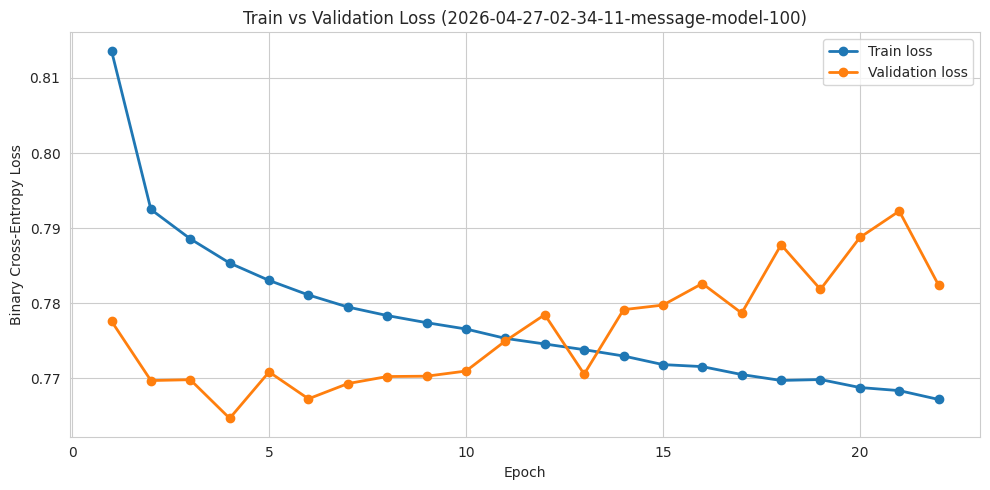

split,train,val
epoch,,
1.0,0.813628,0.777615
2.0,0.792491,0.769709
3.0,0.788576,0.769822
4.0,0.785353,0.764677
5.0,0.783042,0.770854
6.0,0.781106,0.767276
7.0,0.779498,0.769304
8.0,0.778362,0.770243
9.0,0.777415,0.770290


In [6]:
# Plot train/validation loss from the latest training run
model_runs_dir = Path.cwd() / 'models'
metrics_candidates = sorted(
    # model_runs_dir.glob(f'*-{TASK_NODE_TYPE}-model-*/metrics.csv'),
    model_runs_dir.glob(f'2026-04-27-02-34-11-message-model-100/metrics.csv'),
    key=lambda candidate: candidate.stat().st_mtime,
    reverse=True,
)

if not metrics_candidates:
    raise FileNotFoundError(f'No metrics.csv files found under {model_runs_dir}')

metrics_path = metrics_candidates[0]
metrics_df = pd.read_csv(metrics_path)
epoch_metrics = metrics_df[metrics_df['phase'] == 'epoch'].copy()
loss_curves = (
    epoch_metrics.pivot(index='epoch', columns='split', values='loss')
    .sort_index()
)

ax = loss_curves[['train', 'val']].plot(
    marker='o',
    linewidth=2,
    figsize=(10, 5),
    title=f'Train vs Validation Loss ({metrics_path.parent.name})',
)
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.legend(['Train loss', 'Validation loss'])
plt.tight_layout()
plt.show()

loss_curves[['train', 'val']]


In [8]:
metrics_df[(metrics_df['epoch'] == 45)|(metrics_df['phase'] == 'final')]

,phase,epoch,split,loss,general_f1,class_0_f1,class_1_f1,precision,recall,specificity,mcc,tn,fp,fn,tp,pr_auc,roc_auc,learning_rate
88,epoch,45.0,train,0.563559,0.797889,0.840306,0.724791,0.663283,0.798873,0.797398,0.573385,30030,7630,3784,15030,0.813856,0.886053,0.000168
89,epoch,45.0,val,0.592586,0.764998,0.814922,0.678190,0.573399,0.829848,0.737417,0.523999,3648,1299,358,1746,0.784001,0.873749,0.000168
100,final,NaN,train,0.563559,0.797889,0.840306,0.724791,0.663283,0.798873,0.797398,0.573385,30030,7630,3784,15030,0.813856,0.886053,0.000150
101,final,NaN,val,0.592586,0.764998,0.814922,0.678190,0.573399,0.829848,0.737417,0.523999,3648,1299,358,1746,0.784001,0.873749,0.000150
102,final,NaN,test,0.621210,0.756153,0.807718,0.666795,0.570625,0.801953,0.736125,0.500401,3621,1298,426,1725,0.749052,0.859678,0.000150


## Step 8: Train Baseline (RoBerta)

In [ ]:
from src.disinfograph.gnn.graph_builder import deduplicate_forwarded_messages

messages_df_dedup = deduplicate_forwarded_messages(messages_df)
print(f"Before dedup: {len(messages_df)} messages")
print(f"After dedup:  {len(messages_df_dedup)} messages")
print(f"Removed:      {len(messages_df) - len(messages_df_dedup)} forward copies whose source was in the dataset")
print(f"Label distribution after dedup:")
print(messages_df_dedup['label'].value_counts())

Before dedup: 70595 messages
After dedup:  34928 messages
Removed:      35667 forward copies whose source was in the dataset
Label distribution after dedup:
label
0    23572
1    11356
Name: count, dtype: Int64


In [ ]:
from src.disinfograph.gnn.train_roberta_text_baseline import train_roberta_baseline

baseline_results = train_roberta_baseline(
    df=messages_df_dedup,
    task="message",
    model_name="xlm-roberta-base",
    text_col="text",
    label_col="label",
    date_col="date_utc",
    channel_col="channel_id",
    message_id_col="message_id",
    output_dir=Path.cwd() / "models",
    num_epochs=10,
    batch_size=64,
    eval_batch_size=32,
    max_length=128,
    lr=2e-5,
    gradient_accumulation_steps=4,
    # use_mixed_precision=True,
    gradient_checkpointing=True,
    early_stopping_patience=2,
)

baseline_metrics_path = sorted(
    (Path.cwd() / "models").glob("*-message-roberta-text-baseline-5/metrics.csv"),
    key=lambda candidate: candidate.stat().st_mtime,
    reverse=True,
)[0]
baseline_metrics_df = pd.read_csv(baseline_metrics_path)
baseline_metrics_df[baseline_metrics_df["phase"] == "final"]


In [19]:
roberta_results_df = pd.read_csv('/Users/yuliavistak/Desktop/UCU/Навчання/4 курс/diploma/TeleNarratives/src/disinfograph/gnn/models/2026-04-26-10-41-28-message-roberta-text-baseline-10/metrics.csv')

In [20]:
roberta_results_df[roberta_results_df["phase"] == "final"]

,phase,epoch,split,loss,general_f1,class_0_f1,class_1_f1,precision,recall,specificity,mcc,tn,fp,fn,tp,pr_auc,roc_auc,learning_rate
18,final,NaN,train,0.350566,0.891339,0.915896,0.846527,0.795610,0.904407,0.884862,0.766710,16531,2151,885,8373,0.913870,0.957314,0.000002
19,final,NaN,val,0.602472,0.856488,0.898686,0.754050,0.767233,0.741313,0.905092,0.652970,2222,233,268,768,0.836634,0.905723,0.000002
20,final,NaN,test,0.657269,0.831570,0.878532,0.725408,0.718375,0.732580,0.874743,0.604017,2130,305,284,778,0.811189,0.894163,0.000002
